# Reproducción: A Neural Probabilistic Language Model (Bengio et al., 2003)

## Paso 1 — Imports y configuración

In [1]:
import torch
import torch.nn.functional as F
%matplotlib inline
import matplotlib.pyplot as plt
import random

torch.manual_seed(42)
random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Paso 2 — Datos y vocabulario ( |V| )

El paper original entrena a nivel de **palabras** sobre corpus gigantes (Brown: 1.18M
palabras, |V|=16,383 palabras). Nosotros simplificamos deliberadamente: entrenamos a
nivel de **caracteres** sobre 32,033 nombres propios — misma arquitectura matemática,
escala manejable para correr en minutos en una laptop.

1. Carga los nombres
2. Construye el vocabulario: todos los caracteres únicos
3. Crea `stoi` (string→index): el índice numérico de cada carácter
4. Agrega un token especial `"."` (índice 0) que marca inicio/fin de cada nombre
5. `itos` es el diccionario inverso, para traducir de número a carácter cuando generemos nombres nuevos al final

Con 27 tokens totales (26 letras + el separador), nuestra matriz $C$ va a tener forma
$27 \times m$ 

In [2]:
words = open("names.txt", "r", encoding="utf-8").read().splitlines()
print(f"Total de nombres: {len(words)}")
print(f"Ejemplos: {words[:10]}")

chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0  # token especial de inicio/fin de palabra
itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)
print(f"\nVocabulario ({vocab_size} tokens, |V|): {itos}")


Total de nombres: 32033
Ejemplos: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']

Vocabulario (27 tokens, |V|): {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## Paso 3 — Construir el dataset (pares contexto → siguiente carácter)

Aquí traducimos a código la ecuación $x = (C(w_{t-1}), C(w_{t-2}), C(w_{t-3}))$

Solo generamos los **índices** de contexto, todavía
no los vectores (eso lo hace la matriz $C$ en el siguiente paso).

`build_dataset` desliza una ventana de `BLOCK_SIZE=3` caracteres sobre cada nombre. Para
"emma" genera:

-> "e" "..e" -> "m" ".em" -> "m" "emm" -> "a" "mma" -> "."

Cada fila es un ejemplo de entrenamiento: el contexto de 3 caracteres previos (`X`) y el
carácter correcto que debería seguir (`Y`).

**Split 80/10/10** — igual que el paper (que usa train/validación/prueba), pero con una
diferencia: el paper divide su corpus **cronológicamente** porque es texto
corrido; nosotros usamos los nombres al azar porque cada nombre es independiente.



In [3]:
BLOCK_SIZE = 3  # tamaño de contexto

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * BLOCK_SIZE  # arranca con puros tokens "." (padding de inicio)
        for ch in w + ".":          # el "." final marca fin de palabra
            ix = stoi[ch]
            X.append(context)       # el contexto ACTUAL
            Y.append(ix)            # lo que el modelo debe predecir
            context = context[1:] + [ix]  # desliza la ventana: quita el más viejo, agrega ix
    return torch.tensor(X), torch.tensor(Y)

random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])       # 80% entrenamiento
Xdev, Ydev = build_dataset(words[n1:n2])   # 10% validación
Xte, Yte = build_dataset(words[n2:])       # 10% prueba

print(f"train={Xtr.shape[0]}  dev={Xdev.shape[0]}  test={Xte.shape[0]}")
print(f"\nEjemplo — primeros 5 pares (contexto -> siguiente caracter) de '{words[0]}':")
for i in range(min(5, len(Xtr))):
    ctx = ''.join(itos[ix.item()] for ix in Xtr[i])
    print(f"  {ctx!r} -> {itos[Ytr[i].item()]!r}")


train=182625  dev=22655  test=22866

Ejemplo — primeros 5 pares (contexto -> siguiente caracter) de 'yuheng':
  '...' -> 'y'
  '..y' -> 'u'
  '.yu' -> 'h'
  'yuh' -> 'e'
  'uhe' -> 'n'


## Paso 4 — Parámetros del modelo

$$y = b + Wx + U\cdot\tanh(d+Hx)$$

Creamos cada pieza con las dimensiones exactas:

| Símbolo del paper | Variable | Forma | Qué es |
|---|---|---|---|
| $C$ | `C` | $27\times10$ | tabla de embeddings — $\|V\|\times m$ |
| $H$ | `H` | $30\times200$ | pesos de la capa oculta |
| $d$ | `d` | $200$ | sesgo de la capa oculta |
| $U$ | `U` | $200\times27$ | pesos de capa oculta → salida |
| $b$ | `b` | $27$ | sesgo de salida |

$W$ (la conexión directa opcional del paper) la dejamos fija en 0 — no la usamos.



In [4]:
N_EMBD = 10    # dimensión de cada embedding
N_HIDDEN = 200 # neuronas en la capa oculta

g = torch.Generator().manual_seed(42)

# Inicializacion de parametros
C  = torch.randn((vocab_size, N_EMBD), generator=g)                      # tabla de embeddings  |V| x m
H  = torch.randn((BLOCK_SIZE * N_EMBD, N_HIDDEN), generator=g) * 0.1      # pesos capa oculta   (n-1)m x h
d  = torch.randn(N_HIDDEN, generator=g) * 0.01                            # sesgo capa oculta   h
U  = torch.randn((N_HIDDEN, vocab_size), generator=g) * 0.01              # pesos capa salida   h x |V|
b  = torch.randn(vocab_size, generator=g) * 0                             # sesgo capa salida   |V|

parameters = [C, H, d, U, b]
n_params = sum(p.nelement() for p in parameters)
print(f"Número de parámetros: {n_params}")

parameters = [p.to(device).requires_grad_() for p in parameters]
C, H, d, U, b = parameters

# Los TRES splits se mueven juntos. Si dejas test en CPU, evaluarlo más adelante truena
# con "Expected all tensors to be on the same device".
Xtr, Ytr = Xtr.to(device), Ytr.to(device)
Xdev, Ydev = Xdev.to(device), Ydev.to(device)
Xte, Yte = Xte.to(device), Yte.to(device)

Número de parámetros: 11897


## Paso 5 — Forward pass (probar la arquitectura sin entrenar todavía)

Arquitectura matemática:

1. **Lookup** (`C[Xb]`): busca el vector de cada carácter de contexto en la tabla `C`
2. **Concatenar** (`.view(...)`): pega los vectores en uno solo
3. **Capa oculta** (`tanh(x @ H + d)`): transformación lineal + no-linealidad —
   $h = \tanh(d+Hx)$
4. **Logits** (`h @ U + b`): otra transformación lineal, un puntaje por cada uno de los
   27 caracteres del vocabulario — $y = b+Uh$
5. **Loss** (`F.cross_entropy`): aplica softmax internamente y calcula
   $-\log \hat{P}(\text{carácter correcto})$


In [5]:
BATCH_SIZE = 64
ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]

emb = C[Xb]                                          # Paso 1: lookup -> (batch, 3, 10)
x = emb.view(emb.shape[0], -1)                        # Paso 2: concatenar -> (batch, 30)
h = torch.tanh(x @ H + d)                             # Paso 3: capa oculta -> (batch, 200)
logits = h @ U + b                                    # Paso 4: logits -> (batch, 27)
loss = F.cross_entropy(logits, Yb)                    # Paso 5: softmax + -log(prob correcta)

print(f"Forma de emb: {emb.shape}")
print(f"Forma de x (concatenado): {x.shape}")
print(f"Forma de h (capa oculta): {h.shape}")
print(f"Forma de logits: {logits.shape}")
print(f"Loss inicial (sin entrenar, debería ser cercano a ln(27)≈3.30): {loss.item():.4f}")


Forma de emb: torch.Size([64, 3, 10])
Forma de x (concatenado): torch.Size([64, 30])
Forma de h (capa oculta): torch.Size([64, 200])
Forma de logits: torch.Size([64, 27])
Loss inicial (sin entrenar, debería ser cercano a ln(27)≈3.30): 3.2934


## Paso 6 — Entrenamiento (gradiente descendente, miles de pasos)

Aquí implementamos la regla de actualización:

    theta <- theta + epsilon * d(log P_hat)/d(theta)

En cada paso del loop:

1. Forward pass: igual que en el Paso 5 (lookup -> concatenar -> tanh -> logits -> loss),
   pero con un batch nuevo de 64 ejemplos elegidos al azar en cada iteración

2. Backward pass (`loss.backward()`): PyTorch calcula automáticamente todas las derivadas
   parciales de la pérdida respecto a cada parámetro (C, H, d, U, b). 

3. Actualización (`p.data += -lr * p.grad`): aplicamos la regla del paper. El signo es
   negativo porque estamos MINIMIZANDO la cross-entropy (-log P_hat) en vez de MAXIMIZAR
   el log-likelihood directamente -- son matemáticamente equivalentes, solo cambia el signo.

4. Learning rate con decaimiento: bajamos epsilon **a un décimo** (0.1 -> 0.01) después de
   20,000 pasos. El paper usa un esquema parecido (epsilon_t = epsilon_0 / (1 + r*t)) para
   que el entrenamiento converja más fino hacia el final en vez de seguir dando pasos grandes.

Guardamos `lossi` (el loss de cada paso) para graficar la curva más adelante.

> **Nota de reproducibilidad:** la celda del Paso 5 consume el generador `g`. Si re-corres
> el Paso 5 sin re-correr el Paso 4, este entrenamiento arranca desde otro punto del RNG y
> los números cambian. Para reproducir exactamente: corre las celdas en orden desde el Paso 4.

In [6]:
parameters = [C, H, d, U, b]
MAX_STEPS = 30000
BATCH_SIZE = 64
lossi = []

for step in range(MAX_STEPS):
    # forward pass
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    h = torch.tanh(x @ H + d)
    logits = h @ U + b
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # actualización de parámetros
    lr = 0.1 if step < 20000 else 0.01   # a un décimo después de 20k pasos
    for p in parameters:
        p.data += -lr * p.grad

    if step % 2000 == 0:
        print(f"step {step:6d}/{MAX_STEPS}  loss {loss.item():.4f}")
    lossi.append(loss.item())   # loss directo, no log10: así se puede comparar con los baselines

print(f"\nLoss final del último batch: {loss.item():.4f}")

step      0/30000  loss 3.2858


step   2000/30000  loss 2.4892


step   4000/30000  loss 2.2745


step   6000/30000  loss 2.4575


step   8000/30000  loss 2.4699


...

step  22000/30000  loss 2.0594


step  24000/30000  loss 2.1592


step  26000/30000  loss 2.1663


step  28000/30000  loss 2.1387



Loss final del último batch: 2.0857


## Paso 7 — El baseline que el paper quiere vencer (n-gramas de conteo)

Este es el paso sin el cual no hay reproducción, solo implementación.

El paper **no** afirma "los embeddings + MLP funcionan". Afirma que **superan a los
n-gramas de conteo suavizados** — ~24% mejor perplejidad en Brown (Tabla 1). Esa es la
contribución. Si no entrenamos el rival, no probamos nada.

Un n-grama de conteo es exactamente lo que suena: cuenta cuántas veces viste cada
combinación (contexto → siguiente carácter) y normaliza.

$$\hat{P}(w_t \mid w_{t-1},\dots,w_{t-n+1}) = \frac{\text{count}(w_{t-n+1..t}) + \alpha}{\sum_{w}\left[\text{count}(w_{t-n+1..t-1}, w) + \alpha\right]}$$

El $\alpha$ es **suavizado add-alpha**: sin él, cualquier combinación nunca vista en
entrenamiento tendría probabilidad 0, y el loss sería infinito en cuanto apareciera una
sola en validación. Elegimos $\alpha$ probando varios y quedándonos con el mejor en dev
(nunca en test).

Comparamos tres: bigrama (1 carácter de contexto), trigrama (2) y 4-grama (3 — el mismo
contexto que ve nuestro MLP, así que es la comparación justa).

In [7]:
def ngram_baseline(order, alphas=(1.0, 0.1, 0.01, 0.001)):
    """Conteos + suavizado add-alpha. `order` = caracteres de contexto.
    Elige alpha por dev y reporta los tres splits."""

    def flat(X, Y):
        """(contexto, objetivo) -> un solo índice en la tabla aplanada de |V|^(order+1)."""
        f = torch.zeros(len(Y), dtype=torch.long, device=X.device)
        for i in range(order):
            f = f * vocab_size + X[:, BLOCK_SIZE - order + i]
        return f * vocab_size + Y

    counts = torch.bincount(
        flat(Xtr, Ytr), minlength=vocab_size ** (order + 1)
    ).float().view(-1, vocab_size)

    best = None
    for alpha in alphas:
        P = ((counts + alpha) / (counts + alpha).sum(-1, keepdim=True)).view(-1)
        r = {s: -P[flat(X, Y)].log().mean().item()
             for s, (X, Y) in [("train", (Xtr, Ytr)), ("dev", (Xdev, Ydev)), ("test", (Xte, Yte))]}
        r["alpha"] = alpha
        if best is None or r["dev"] < best["dev"]:
            best = r

    # qué tan densa quedó la tabla: la clave para entender el resultado
    best["contextos_posibles"] = vocab_size ** order
    best["contextos_vistos"] = int((counts.sum(-1) > 0).sum())
    return best


baselines = {}
print(f"{'modelo':>10} | {'train':>7} {'dev':>7} {'test':>7} | {'contextos vistos':>22}")
print("-" * 68)
for order, name in [(1, "bigrama"), (2, "trigrama"), (3, "4-grama")]:
    r = baselines[name] = ngram_baseline(order)
    cob = 100 * r["contextos_vistos"] / r["contextos_posibles"]
    print(f"{name:>10} | {r['train']:>7.4f} {r['dev']:>7.4f} {r['test']:>7.4f} | "
          f"{r['contextos_vistos']:>7}/{r['contextos_posibles']:<7} ({cob:4.1f}%)")

best_ngram_name = min(baselines, key=lambda k: baselines[k]["dev"])
best_ngram = baselines[best_ngram_name]
print(f"\nMejor baseline: {best_ngram_name}, dev loss {best_ngram['dev']:.4f} "
      f"(perplejidad {torch.exp(torch.tensor(best_ngram['dev'])):.2f})")

    modelo |   train     dev    test |       contextos vistos
--------------------------------------------------------------------
   bigrama |  2.4542  2.4531  2.4580 |      27/27      (100.0%)
  trigrama |  2.1874  2.2225  2.2240 |     595/729     (81.6%)
   4-grama |  1.9187  2.1018  2.1044 |    5438/19683   (27.6%)

Mejor baseline: 4-grama, dev loss 2.1018 (perplejidad 8.18)


## Paso 8 — Evaluación en los tres splits + el veredicto

Evaluamos sobre train (182,625 filas), dev (22,655) y **test (22,866)**. El test se toca
una sola vez, al final: es la métrica que reporta el paper y la única que no se contaminó
eligiendo hiperparámetros.

Dos lecturas distintas de los números:

- **`train` vs `dev`** dice si el modelo memorizó. Un gap chico significa que generaliza.
- **`dev` del MLP vs `dev` del n-grama** dice si la idea del paper funciona *aquí*. Ésta
  es la comparación que importa, y es la que decide si la reproducción salió o no.

Perplejidad = exp(loss): mide entre cuántas opciones "duda" el modelo en promedio.

In [8]:
import math

@torch.no_grad()
def split_loss(X, Y):
    emb = C[X]
    x = emb.view(emb.shape[0], -1)
    h = torch.tanh(x @ H + d)
    logits = h @ U + b
    return F.cross_entropy(logits, Y).item()

mlp = {"train": split_loss(Xtr, Ytr), "dev": split_loss(Xdev, Ydev), "test": split_loss(Xte, Yte)}

print(f"{'modelo':>10} | {'train':>7} {'dev':>7} {'test':>7} | {'ppl dev':>8}")
print("-" * 50)
for name, r in list(baselines.items()) + [("MLP", mlp)]:
    print(f"{name:>10} | {r['train']:>7.4f} {r['dev']:>7.4f} {r['test']:>7.4f} | "
          f"{math.exp(r['dev']):>8.2f}")

gap = mlp["dev"] - mlp["train"]
delta = (1 - mlp["dev"] / best_ngram["dev"]) * 100
print(f"\nGap train/dev del MLP: {gap:+.4f}  -> generaliza, no memorizó")
print(f"Gap train/dev del {best_ngram_name}: {best_ngram['dev'] - best_ngram['train']:+.4f}"
      f"  -> memoriza mucho más")
print(f"\nVEREDICTO: el MLP {'GANA' if delta > 0 else 'PIERDE'} por {abs(delta):.1f}% "
      f"contra el {best_ngram_name} en dev.")

    modelo |   train     dev    test |  ppl dev
--------------------------------------------------
   bigrama |  2.4542  2.4531  2.4580 |    11.62
  trigrama |  2.1874  2.2225  2.2240 |     9.23
   4-grama |  1.9187  2.1018  2.1044 |     8.18
       MLP |  2.1168  2.1412  2.1429 |     8.51

Gap train/dev del MLP: +0.0244  -> generaliza, no memorizó
Gap train/dev del 4-grama: +0.1830  -> memoriza mucho más

VEREDICTO: el MLP PIERDE por 1.9% contra el 4-grama en dev.


### La curva de entrenamiento, legible

Graficar `lossi` crudo no sirve: con `BATCH_SIZE=64` el loss por batch oscila en un rango
de ±0.6, mientras que la señal que queremos ver (la mejora entre el paso 10,000 y el
30,000) es de ~0.06. **El ruido es ~18× la señal** y la gráfica sale como una mancha
sólida donde no se distingue nada — ni siquiera el efecto del cambio de learning rate.

La solución es separar señal de ruido: el crudo en gris de fondo, y encima una **media
móvil de 250 pasos**. Y ponemos los baselines como líneas de referencia en el mismo eje,
que es lo que convierte la gráfica en un argumento en vez de un adorno.

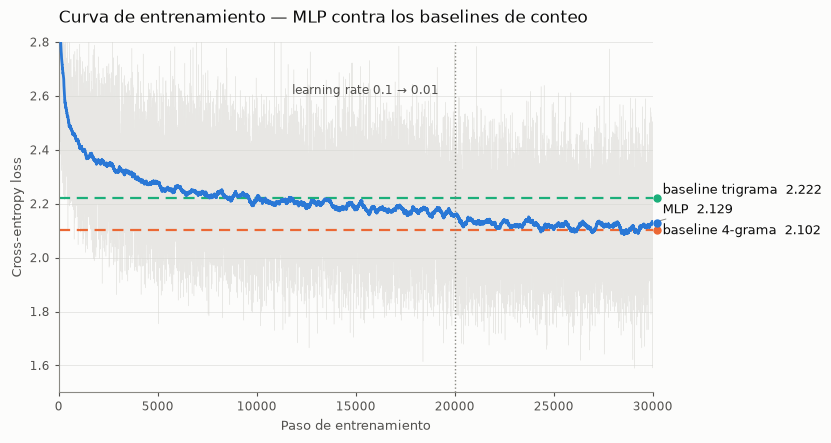

In [9]:
from viz import PALETTE, style_axes

W = 250   # ventana de la media móvil
smooth = [sum(lossi[max(0, i - W):i + 1]) / len(lossi[max(0, i - W):i + 1])
          for i in range(len(lossi))]

fig, ax = plt.subplots(figsize=(9, 4.8), facecolor=PALETTE["surface"])
ax.plot(lossi, color=PALETTE["band"], lw=0.35, alpha=0.55, zorder=1)          # ruido crudo
ax.axhline(baselines["trigrama"]["dev"], color=PALETTE["s3"], lw=1.6, ls=(0, (5, 3)), zorder=2)
ax.axhline(baselines["4-grama"]["dev"], color=PALETTE["s2"], lw=1.6, ls=(0, (5, 3)), zorder=2)
ax.plot(smooth, color=PALETTE["s1"], lw=2, zorder=4)                          # señal
ax.axvline(20000, color=PALETTE["ink3"], lw=1, ls=":", zorder=3)
ax.annotate("learning rate 0.1 → 0.01", xy=(20000, 2.62), xytext=(19200, 2.62),
            ha="right", va="center", fontsize=8.5, color=PALETTE["ink2"])

# etiquetas directas (nunca identificar series solo por color), separadas si se encimarían
labels = sorted([(smooth[-1], f"MLP  {smooth[-1]:.3f}", PALETTE["s1"]),
                 (baselines["4-grama"]["dev"], f"baseline 4-grama  {baselines['4-grama']['dev']:.3f}", PALETTE["s2"]),
                 (baselines["trigrama"]["dev"], f"baseline trigrama  {baselines['trigrama']['dev']:.3f}", PALETTE["s3"])])
placed = []
for y, txt, col in labels:
    ly = y if not placed else max(y, placed[-1] + 0.075)
    placed.append(ly)
    ax.annotate(txt, xy=(MAX_STEPS, y), xytext=(MAX_STEPS + 500, ly), va="center",
                fontsize=9, color=PALETTE["ink"],
                arrowprops=dict(arrowstyle="-", color=PALETTE["ink3"], lw=0.7,
                                shrinkA=0, shrinkB=2) if abs(ly - y) > 1e-9 else None)
    ax.plot([MAX_STEPS + 200], [y], marker="o", ms=5, color=col, clip_on=False, zorder=5)

ax.set_xlim(0, MAX_STEPS)
ax.set_ylim(1.5, 2.8)
style_axes(ax, "Curva de entrenamiento — MLP contra los baselines de conteo",
           "Paso de entrenamiento", "Cross-entropy loss")
fig.subplots_adjust(right=0.74, left=0.08, top=0.86, bottom=0.13)
fig.savefig("loss_curve.png", dpi=160, facecolor=PALETTE["surface"])
plt.show()

## Paso 9 — Generación de nombres nuevos (muestreo del modelo entrenado)

Esta celda pone a prueba, de forma cualitativa, lo que el modelo aprendió. En vez de
tomar siempre el carácter más probable (lo cual daría resultados repetitivos y aburridos),
usamos `torch.multinomial` para MUESTREAR de la distribución de probabilidad completa que
entrega el softmax -- así el modelo puede generar variedad real, no solo su predicción #1.

El proceso, carácter por carácter:
1. Arranca con un contexto de puros tokens "." (equivalente a "inicio de nombre")
2. Calcula la distribución de probabilidad del siguiente carácter (el mismo forward pass
   de siempre: lookup -> concatenar -> tanh -> logits -> softmax)
3. Muestrea UN carácter de esa distribución (no determinista)
4. Desliza la ventana de contexto (quita el carácter más viejo, agrega el nuevo)
5. Repite hasta que el modelo mismo "decide" generar el token "." -- fin del nombre

Al final comparamos cada nombre generado contra el dataset original (`words`).

> **Cuidado con la interpretación:** que un nombre generado *no* esté en `names.txt` es
> evidencia débil de "creatividad", y que sí esté no es evidencia de memorización. Con
> nombres de 3-4 caracteres hay pocas combinaciones plausibles, así que el modelo
> reconstruye `don` o `mar` por pura estadística de caracteres, sin haberlos guardado.
> Es un complemento cualitativo al loss, no una métrica.

In [10]:
g_dev = torch.Generator(device=device).manual_seed(42)  # generador en el mismo device que el modelo
MAX_NAME_LEN = 32   # cota de seguridad: nada garantiza que el modelo emita "." alguna vez

@torch.no_grad()
def generate(n=20):
    names = []
    for _ in range(n):
        out = []
        context = [0] * BLOCK_SIZE
        while len(out) < MAX_NAME_LEN:
            emb = C[torch.tensor([context], device=device)]
            x = emb.view(1, -1)
            h = torch.tanh(x @ H + d)
            logits = h @ U + b
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=g_dev).item()
            context = context[1:] + [ix]
            if ix == 0:
                break
            out.append(itos[ix])
        names.append("".join(out))
    return names

generated = generate(20)
existing = set(words)
new_ones = [n for n in generated if n not in existing]

print("Nombres generados por el modelo:")
for name in generated:
    print(f"  {name:<16}{'(nuevo)' if name not in existing else '(ya existe en names.txt)'}")

print(f"\n{len(new_ones)}/{len(generated)} no aparecen en el dataset")
print("Los que sí aparecen no son un error: son nombres cortos y frecuentes cuyo patrón")
print("es tan común que el modelo los reconstruye sin haberlos memorizado.")

Nombres generados por el modelo:
  krita           (nuevo)
  elle            (ya existe en names.txt)
  rapon           (nuevo)
  dagar           (nuevo)
  ever            (ya existe en names.txt)
  mairishaiyah    (nuevo)
  branivi         (nuevo)
  breigh          (nuevo)
  margemin        (nuevo)
  wyson           (nuevo)
  dion            (ya existe en names.txt)
  mausincelos     (nuevo)
  sarmin          (nuevo)
  vies            (nuevo)
  dar             (nuevo)
  krishay         (ya existe en names.txt)
  kadcy           (nuevo)
  dot             (ya existe en names.txt)
  don             (ya existe en names.txt)
  makeell         (nuevo)

14/20 no aparecen en el dataset
Los que sí aparecen no son un error: son nombres cortos y frecuentes cuyo patrón
es tan común que el modelo los reconstruye sin haberlos memorizado.


In [11]:
import json

results = {
    "paper": "Bengio et al. 2003 - A Neural Probabilistic Language Model",
    "reproduccion": "nivel de caracteres, 32,033 nombres propios (dataset karpathy/makemore)",
    "arquitectura": {
        "vocab_size": vocab_size,
        "block_size (n-1)": BLOCK_SIZE,
        "n_embd (m)": N_EMBD,
        "n_hidden (h)": N_HIDDEN,
        "n_params": n_params,
    },
    "mlp": {k: round(v, 4) for k, v in mlp.items()}
           | {f"perplexity_{k}": round(math.exp(v), 2) for k, v in mlp.items()},
    "baselines_ngrama": {
        name: {k: (round(v, 4) if isinstance(v, float) else v) for k, v in r.items()}
        for name, r in baselines.items()
    },
    "veredicto": {
        "mejor_ngrama": best_ngram_name,
        "delta_dev_pct": round(delta, 2),
        "resumen": f"el MLP {'GANA' if delta > 0 else 'PIERDE'} por {abs(delta):.1f}% contra el {best_ngram_name}",
    },
    "nombres_generados": generated,
    "nombres_no_en_dataset": new_ones,
}

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(json.dumps(results, indent=2, ensure_ascii=False))

{
  "paper": "Bengio et al. 2003 - A Neural Probabilistic Language Model",
  "reproduccion": "nivel de caracteres, 32,033 nombres propios (dataset karpathy/makemore)",
  "arquitectura": {
    "vocab_size": 27,
    "block_size (n-1)": 3,
    "n_embd (m)": 10,
    "n_hidden (h)": 200,
    "n_params": 11897
  },
  "mlp": {
    "train": 2.1168,
    "dev": 2.1412,
    "test": 2.1429,
    "perplexity_train": 8.3,
    "perplexity_dev": 8.51,
    "perplexity_test": 8.52
  },
  "baselines_ngrama": {
    "bigrama": {
      "train": 2.4542,
      "dev": 2.4531,
      "test": 2.458,
      "alpha": 0.1,
      "contextos_posibles": 27,
      "contextos_vistos": 27
    },
    "trigrama": {
      "train": 2.1874,
      "dev": 2.2225,
      "test": 2.224,
      "alpha": 0.1,
      "contextos_posibles": 729,
      "contextos_vistos": 595
    },
    "4-grama": {
      "train": 1.9187,
      "dev": 2.1018,
      "test": 2.1044,
      "alpha": 0.1,
      "contextos_posibles": 19683,
      "contextos_vistos

## Paso 9b — ¿Qué aprendió realmente la matriz $C$?

Todo el paper descansa en una afirmación sobre la tabla de embeddings: que tokens que se
*comportan* parecido terminan *cerca* en el espacio vectorial, y que ahí nace la
generalización. Hasta aquí lo dimos por hecho. Vamos a verlo.

El truco es entrenar el mismo modelo con **m=2** — embeddings de 2 dimensiones — para
poder graficarlos directamente, sin PCA ni t-SNE de por medio. Cuesta un poco de loss
(2 dimensiones son pocas), pero a cambio vemos la tabla $C$ tal cual es.

Nadie le dijo al modelo qué es una vocal. Solo vio secuencias de caracteres.


=== 3. EMBEDDINGS: ¿qué aprendió la matriz C? ===



m=2 -> train 2.2846  dev 2.2832
-> embeddings.png


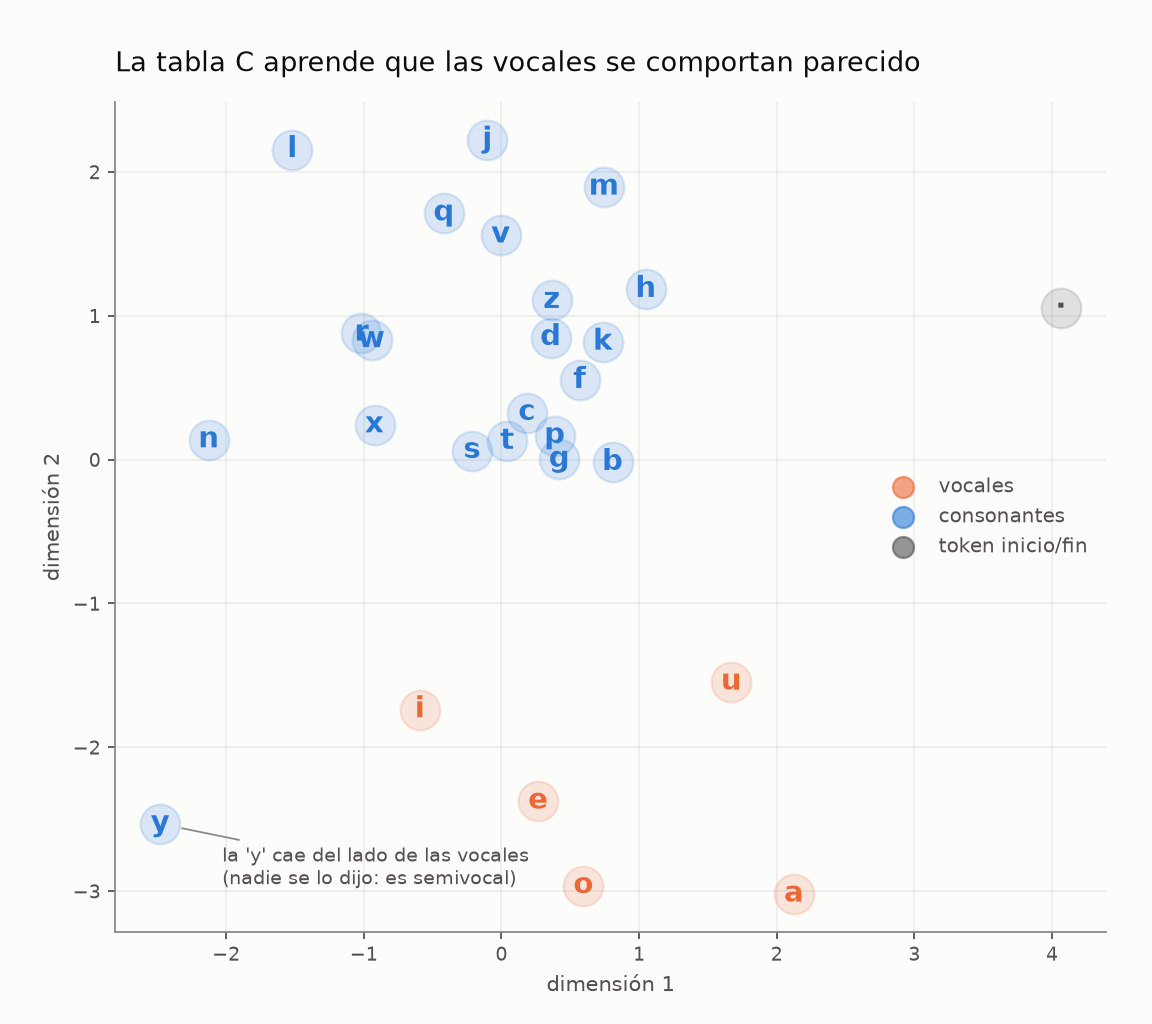

In [12]:
# analysis.py tiene el mismo modelo parametrizado: lo reusamos en vez de duplicarlo aquí.
# (~40 s: entrena una vez con m=2)
from analysis import exp_embeddings

emb_result = exp_embeddings()          # entrena, grafica y guarda embeddings.png

from IPython.display import Image, display
display(Image("embeddings.png"))

## Paso 10 — Conclusiones

### El resultado incómodo

Con la configuración base, **el MLP pierde contra el 4-grama de conteo**:

| Modelo | train | dev | test | perplejidad dev |
|---|---|---|---|---|
| Bigrama | 2.4542 | 2.4531 | 2.4580 | 11.62 |
| Trigrama | 2.1874 | 2.2225 | 2.2240 | 9.23 |
| **4-grama** | 1.9187 | **2.1018** | **2.1044** | **8.18** |
| **MLP (11,897 params)** | 2.1168 | 2.1412 | 2.1429 | 8.51 |

Con el mismo contexto de 3 caracteres, contar y suavizar le gana a la red por 1.9%.

**Esto no es un bug — es la respuesta correcta, y explica el paper mejor que si hubiera
ganado.** La "maldición de la dimensionalidad" que Bengio et al. resuelven **no existe con
|V|=27**: hay 27³ = 19,683 contextos posibles y 182,625 ejemplos de entrenamiento, así que
el 27.6% de los contextos ya se vio y los conteos son densos. El paper necesitaba
|V|=17,000 (17,000³ ≈ 5×10¹² contextos) para que la dispersión hundiera al n-grama.

Hay un matiz que sí favorece al MLP, y es el mecanismo del paper asomándose: el 4-grama
tiene un gap train/dev de **+0.183** (memoriza), el MLP de **+0.024** (generaliza). El MLP
generaliza mucho mejor; simplemente no tiene suficiente capacidad para convertir eso en
ventaja.

### Dónde sí gana: el experimento de contexto

Creciendo el contexto sobre estos mismos nombres aparece la dispersión y el resultado se
invierte (`python analysis.py contexto`):

| ctx | contextos vistos / posibles | N-grama dev | MLP dev |
|---|---|---|---|
| 1 | 27 / 27 (100%) | **2.4531** | 2.4602 |
| 2 | 595 / 729 (81.6%) | **2.2225** | 2.2527 |
| 3 | 5,438 / 19,683 (27.6%) | **2.1018** | 2.1414 |
| 4 | 20,243 / 531,441 (3.8%) | 2.1522 | **2.0919** |
| 5 | 36,544 / 14,348,907 (0.3%) | 2.3175 | **2.0754** |
| 6 | tabla de 84 GB | *no cabe en memoria* | **2.0696** |

El n-grama toca fondo en ctx=3 y a partir de ahí **empeora**, porque la cobertura de
contextos colapsa de 27.6% a 0.3%: cada vez más predicciones caen en contextos nunca
vistos y el suavizado tiene que inventar la respuesta. El MLP mejora monotónicamente.

En ctx=6 la tabla de conteo pediría 27⁷ ≈ 10,460 millones de celdas (**84 GB**) y
simplemente no cabe, mientras el MLP solo crece 2,000 parámetros por carácter extra:
**exponencial contra lineal**. Ésa es, literalmente, la tesis del paper.

Tres comparaciones distintas, para no exagerar el resultado:

| Comparación | Resultado |
|---|---|
| A contexto igual (3) | el MLP **pierde** 1.9% |
| A contexto igual (5) | el MLP **gana** 10.4% |
| Mejor MLP (ctx=6) vs mejor n-grama (ctx=3) | el MLP **gana** 1.5% |

### El modelo base está underfitting

Un gap train/dev chico se lee fácil como "no hay overfitting", pero la lectura útil es
otra — el dev loss **sigue bajando** al crecer el modelo (`python analysis.py capacidad`):

| m / h | params | train | dev | gap |
|---|---|---|---|---|
| 2 / 100 | 3,481 | 2.2778 | 2.2745 | −0.003 |
| 5 / 150 | 6,612 | 2.1894 | 2.1960 | +0.007 |
| **10 / 200 (base)** | 11,897 | 2.1171 | 2.1414 | +0.024 |
| 20 / 300 | 26,967 | 2.0637 | 2.1065 | +0.043 |
| 30 / 500 | 59,837 | 2.0347 | 2.0909 | +0.056 |
| 50 / 800 | 143,777 | 2.0112 | **2.0818** | +0.071 |

Con 143,777 parámetros el MLP también supera al 4-grama (2.0818 vs 2.1018), sin tocar el
contexto. O sea: el modelo base tenía dos limitaciones a la vez, contexto y capacidad.

### Comparación con el paper original

| | Paper (Bengio et al. 2003) | Esta reproducción |
|---|---|---|
| Nivel | palabras | caracteres |
| Vocabulario \|V\| | 16,383 (Brown) / 17,964 (AP News) | 27 |
| Contexto (n-1) | 5 (mejor modelo) | 3 |
| Embedding (m) | 30 | 10 |
| Capa oculta (h) | 100 | 200 |
| Parámetros | ~millones | 11,897 |
| Cómputo | 3 semanas, 40 CPUs | ~1 min, 1 GPU (RTX 4050) |
| Perplejidad **test** | 252 | **8.52** |
| Mejora vs mejor n-grama | **+24%** | **−1.9%** base · **+10.4%** a ctx=5 |

Las perplejidades absolutas **no son comparables**: nosotros elegimos entre 27 caracteres,
el paper entre 17,000 palabras. Lo comparable es la última fila — la mejora relativa
contra el baseline, que es la afirmación real del paper.

### Conclusión

El mecanismo del paper funciona, pero **solo cuando el problema lo necesita**. A |V|=27 y
contexto corto, contar sigue siendo mejor: la red paga el costo de aprender una
representación sin cobrar el beneficio. En cuanto el espacio de contextos crece más allá
de lo contable, la ventaja se invierte y no vuelve atrás.

Reproducir el paper no era entrenar el MLP. Era encontrar el punto donde deja de ser
opcional.

### Cierre — la conclusión, generada desde los números

Todo lo de arriba está escrito a mano. Eso es un riesgo: si mañana cambias `N_HIDDEN` o
`BLOCK_SIZE` y vuelves a correr, las tablas de esta sección se quedan diciendo lo de
antes, y el notebook empieza a afirmar cosas que sus propias celdas ya contradicen.

La última celda evita eso: arma el veredicto desde las variables vivas de esta corrida.
Si los números cambian, la conclusión cambia con ellos — incluso el *signo* del resultado,
porque el texto de "por qué" está bifurcado según si el MLP gana o pierde.

In [13]:
# Ficha de cierre: se arma con los números de ESTA corrida, no con prosa escrita a mano.
# Si mañana cambias un hiperparámetro y los resultados se mueven, la conclusión se mueve
# con ellos. (Escribir las conclusiones a mano es exactamente como se cuelan en un repo
# las afirmaciones que ya dejaron de ser ciertas.)

gano = delta > 0
cobertura = 100 * best_ngram["contextos_vistos"] / best_ngram["contextos_posibles"]
linea = "─" * 74

print(linea)
print("  REPRODUCCIÓN — Bengio et al. (2003), A Neural Probabilistic Language Model")
print(linea)
print(f"  Escala   : caracteres · |V|={vocab_size} · contexto={BLOCK_SIZE} · {n_params:,} parámetros")
print(f"  Datos    : {len(words):,} nombres → {Xtr.shape[0]:,} ejemplos de entrenamiento")
print()
print(f"  MLP          dev {mlp['dev']:.4f}   test {mlp['test']:.4f}   "
      f"perplejidad {math.exp(mlp['test']):.2f}")
print(f"  {best_ngram_name:<12} dev {best_ngram['dev']:.4f}   test {best_ngram['test']:.4f}   "
      f"perplejidad {math.exp(best_ngram['test']):.2f}")
print()
print(f"  VEREDICTO: el MLP {'GANA' if gano else 'PIERDE'} por {abs(delta):.1f}% "
      f"contra el mejor baseline de conteo.")
print(linea)

if not gano:
    print(f"""
  POR QUÉ, Y POR QUÉ IMPORTA

  Con |V|={vocab_size} hay {best_ngram['contextos_posibles']:,} contextos posibles y {Xtr.shape[0]:,} ejemplos,
  así que el {cobertura:.1f}% de los contextos ya se vio en entrenamiento. Los conteos son
  DENSOS: no hay dispersión que castigar, y por lo tanto no queda nada que la
  red pueda resolver mejor que una tabla.

  Bengio et al. no eligieron |V|=17,000 por ambición: lo eligieron porque es el
  régimen donde su método deja de ser opcional. Nosotros elegimos un problema
  demasiado fácil para su propia solución.

  El mecanismo igual se asoma en la generalización:
    gap train/dev del MLP        {mlp['dev'] - mlp['train']:+.4f}
    gap train/dev del {best_ngram_name:<12} {best_ngram['dev'] - best_ngram['train']:+.4f}   ({(best_ngram['dev'] - best_ngram['train']) / (mlp['dev'] - mlp['train']):.1f}x peor)

  El n-grama memoriza; el MLP aprende el patrón. Solo que a esta escala memorizar
  todavía alcanza para ganar.
""")
else:
    print("\n  El modelo neuronal supera al conteo: estamos en el régimen del paper.\n")

print(linea)
print("  Reproducir este paper no era entrenar el MLP.")
print("  Era encontrar el punto donde deja de ser opcional.")
print()
print("  Ese punto está medido en `python analysis.py contexto`: con 4 caracteres")
print("  de contexto el resultado se invierte, y con 6 la tabla de conteo ya pide")
print("  84 GB y no cabe en memoria.")
print(linea)

──────────────────────────────────────────────────────────────────────────
  REPRODUCCIÓN — Bengio et al. (2003), A Neural Probabilistic Language Model
──────────────────────────────────────────────────────────────────────────
  Escala   : caracteres · |V|=27 · contexto=3 · 11,897 parámetros
  Datos    : 32,033 nombres → 182,625 ejemplos de entrenamiento

  MLP          dev 2.1412   test 2.1429   perplejidad 8.52
  4-grama      dev 2.1018   test 2.1044   perplejidad 8.20

  VEREDICTO: el MLP PIERDE por 1.9% contra el mejor baseline de conteo.
──────────────────────────────────────────────────────────────────────────

  POR QUÉ, Y POR QUÉ IMPORTA

  Con |V|=27 hay 19,683 contextos posibles y 182,625 ejemplos,
  así que el 27.6% de los contextos ya se vio en entrenamiento. Los conteos son
  DENSOS: no hay dispersión que castigar, y por lo tanto no queda nada que la
  red pueda resolver mejor que una tabla.

  Bengio et al. no eligieron |V|=17,000 por ambición: lo eligieron porque es el
 